In [100]:
# Load and inspect the e-commerce events dataset
# Load the events dataset

import pandas as pd

print("Pandas version:", pd.__version__)

# Load the raw event data from the project folder
events_df = pd.read_csv("events.csv")


# Display the number of rows and columns
print("Dataset dimensions:", events_df.shape)

# Display the first five records
display(events_df.head())



Pandas version: 3.0.6
Dataset dimensions: (2756101, 5)


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


# E-commerce Funnel & Product Conversion Analytics

## Project Overview

This project analyzes e-commerce visitor behavior, product engagement, funnel performance, and transaction activity using Python, Pandas, and Matplotlib.

The analysis focuses on identifying major funnel drop-offs, understanding visitor engagement patterns, evaluating product-level conversion performance, and identifying potential opportunities for further investigation.

**Dataset:** Retailrocket E-commerce Dataset  
**Tools:** Python, Pandas, Matplotlib


## 1. Data Loading & Initial Inspection

Inspect the dataset structure, data types, and missing values.


In [101]:
# Inspect the data types of each column

#show the data type and the number of non-null values for each column
events_df.info(show_counts=True)

#Display the data types in a compact format
print("\nColumn data types:")
print(events_df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   timestamp      2756101 non-null  int64  
 1   visitorid      2756101 non-null  int64  
 2   event          2756101 non-null  str    
 3   itemid         2756101 non-null  int64  
 4   transactionid  22457 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 105.1 MB

Column data types:
timestamp          int64
visitorid          int64
event                str
itemid             int64
transactionid    float64
dtype: object


In [102]:
# Check for missing values in the dataset

# Count missing values in each column
missing_coounts = events_df.isnull().sum()

# Calculate the percentage of missing values in each column
missing_percentage = (
    (missing_coounts / len(events_df)) * 100
).round(2)

#Combine the missing values and percentage into a DataFrame for better visualization
missing_summary = pd.DataFrame({
    "Missing_values": missing_coounts,
    "Missing_Percentage": missing_percentage
})

# Display the missing values summary

print("\nMissing values summary:")
display(missing_summary)




Missing values summary:


,Missing_values,Missing_Percentage
timestamp,0,0.00
visitorid,0,0.00
event,0,0.00
itemid,0,0.00
transactionid,2733644,99.19


In [103]:
# Check exact duplicate records 
duplicate_records = events_df.duplicated().sum()
print(f"\nNumber of duplicate records: {duplicate_records}")

# Inspect the rows that belong to duplicate groups 
duplicate_rows = events_df[
    events_df.duplicated(keep=False)
]
print('\nRows involved in duplicate groups:')
print(duplicate_rows.head(10))  # Display the first 10 rows of duplicate groups

#Show the event type represented in these duplicate groups
print("\nEvent types in duplicate groups:")
display(duplicate_rows['event'].value_counts())


Number of duplicate records: 460

Rows involved in duplicate groups:
           timestamp  visitorid      event  itemid  transactionid
13734  1433180781440    1045411  addtocart  379647            NaN
22404  1433180781440    1045411  addtocart  379647            NaN
24476  1433274223925     366538  addtocart  252068            NaN
25508  1433265100661     198153  addtocart   48715            NaN
27095  1433270868154    1268755       view   60980            NaN
34465  1433274223925     366538  addtocart  252068            NaN
34578  1433277134682     555487  addtocart  397642            NaN
39738  1433265100661     198153  addtocart   48715            NaN
41774  1433270868154    1268755       view   60980            NaN
42469  1433277134682     555487  addtocart  397642            NaN

Event types in duplicate groups:


event
addtocart    732
view         186
Name: count, dtype: int64

In [104]:
# Assess the impact of exact duplicates 
#Count events before removing duplicates
event_before = events_df['event'].value_counts()

#Create a seperate DataFrame Without duplicates
events_df_no_duplicates = events_df.drop_duplicates().copy()

# Count events after removing exact duplicates
event_after = events_df_no_duplicates['event'].value_counts()

# Compare the counts before and after removing duplicates
duplicate_impact = pd.DataFrame({
    'Before_Duplicates': event_before,
    'After_Duplicates': event_after
}).fillna(0).astype(int)

# Calculate  how many records were removed for each event type
duplicate_impact['Rows_removed'] = (
    duplicate_impact['Before_Duplicates'] - duplicate_impact['After_Duplicates']
)

print("\nImpact of removing exact duplicates:")
display(duplicate_impact)

#Verify the total number of rows removed
print("\nOriginal row count:", len(events_df))
print("Row count after deduplication:", len(events_df_no_duplicates))
print("Rows removed:", len(events_df) - len(events_df_no_duplicates))


Impact of removing exact duplicates:


,Before_Duplicates,After_Duplicates,Rows_removed
event,,,
view,2664312,2664218,94
addtocart,69332,68966,366
transaction,22457,22457,0



Original row count: 2756101
Row count after deduplication: 2755641
Rows removed: 460


## 2. Data Cleaning & Timestamp Preparation

Validate duplicates and convert the event timestamp into a readable datetime field.


In [105]:

# Convert timestamps from milliseconds to datetime

# Create a readable datetime column without changing the raw timestamp
events_df_no_duplicates["event_datetime"] = pd.to_datetime(
    events_df_no_duplicates["timestamp"],
    unit="ms"
)

# Display the earliest and latest events
print("Earliest event:")
print(events_df_no_duplicates["event_datetime"].min())

print("\nLatest event:")
print(events_df_no_duplicates["event_datetime"].max())

# Display sample records with readable dates
display(
    events_df_no_duplicates[
        ["timestamp", "event_datetime", "visitorid", "event", "itemid"]
    ].head(10)
)


Earliest event:
2015-05-03 03:00:04.384000

Latest event:
2015-09-18 02:59:47.788000


,timestamp,event_datetime,visitorid,event,itemid
0,1433221332117,2015-06-02 05:02:12.117,257597,view,355908
1,1433224214164,2015-06-02 05:50:14.164,992329,view,248676
2,1433221999827,2015-06-02 05:13:19.827,111016,view,318965
3,1433221955914,2015-06-02 05:12:35.914,483717,view,253185
4,1433221337106,2015-06-02 05:02:17.106,951259,view,367447
5,1433224086234,2015-06-02 05:48:06.234,972639,view,22556
6,1433221923240,2015-06-02 05:12:03.240,810725,view,443030
7,1433223291897,2015-06-02 05:34:51.897,794181,view,439202
8,1433220899221,2015-06-02 04:54:59.221,824915,view,428805
9,1433221204592,2015-06-02 05:00:04.592,339335,view,82389


In [106]:
# Validate the dataset's observation period

# Find the earliest event across all records
earliest_event = events_df_no_duplicates["event_datetime"].min()

# Find the latest event across all records
latest_event = events_df_no_duplicates["event_datetime"].max()

# Calculate the total observation period in days
observation_days = (
    latest_event - earliest_event
).total_seconds() / (24 * 60 * 60)

print("Earliest event:", earliest_event)
print("Latest event:", latest_event)
print("Observation period in days:", round(observation_days, 2))

Earliest event: 2015-05-03 03:00:04.384000
Latest event: 2015-09-18 02:59:47.788000
Observation period in days: 138.0


## 3. Event Distribution & Dataset Profile

Understand the distribution of views, add-to-cart events, and transactions.


In [107]:
# Analyze event distribution after deduplication

# Count each event type in the cleaned dataset
event_summary = (
    events_df_no_duplicates["event"]
    .value_counts()
    .reset_index()
)

# Rename the columns for clarity
event_summary.columns = ["event_type", "event_count"]

# Calculate the percentage of total events
event_summary["percentage"] = (
    event_summary["event_count"]
    / len(events_df_no_duplicates)
    * 100
).round(2)

# Display the results
display(event_summary)

,event_type,event_count,percentage
0,view,2664218,96.68
1,addtocart,68966,2.50
2,transaction,22457,0.81


## 4. Visitor & Funnel Analysis

Analyze visitor reach and progression across the observed funnel stages.


In [108]:
# Count unique visitors and products

# Count distinct visitors in the cleaned dataset
unique_visitors = events_df_no_duplicates["visitorid"].nunique()

# Count distinct products in the cleaned dataset
unique_products = events_df_no_duplicates["itemid"].nunique()

# Display the results
print("Unique visitors:", unique_visitors)
print("Unique products:", unique_products)

Unique visitors: 1407580
Unique products: 235061


In [109]:
# Count unique visitors for each event type

# Group events by event type and count distinct visitors
visitors_by_event = (
    events_df_no_duplicates
    .groupby("event")["visitorid"]
    .nunique()
    .reset_index()
)

# Rename columns for clarity
visitors_by_event.columns = [
    "event_type",
    "unique_visitors"
]

# Display the results
display(visitors_by_event)

,event_type,unique_visitors
0,addtocart,37722
1,transaction,11719
2,view,1404179


In [110]:
#  Calculate preliminary visitor conversion rates

# Extract unique visitor counts for each event type
view_visitors = events_df_no_duplicates.loc[
    events_df_no_duplicates["event"] == "view",
    "visitorid"
].nunique()

cart_visitors = events_df_no_duplicates.loc[
    events_df_no_duplicates["event"] == "addtocart",
    "visitorid"
].nunique()

transaction_visitors = events_df_no_duplicates.loc[
    events_df_no_duplicates["event"] == "transaction",
    "visitorid"
].nunique()

# Calculate preliminary rates using all visitors in each event category
view_to_cart_rate = (cart_visitors / view_visitors) * 100

view_to_transaction_rate = (
    transaction_visitors / view_visitors
) * 100

# Display results
print("View-to-cart rate:", round(view_to_cart_rate, 2), "%")
print(
    "View-to-transaction rate:",
    round(view_to_transaction_rate, 2),
    "%"
)

View-to-cart rate: 2.69 %
View-to-transaction rate: 0.83 %


In [111]:
# Create visitor-level event flags

# Create one row per visitor and identify which event types they performed
visitor_funnel = (
    events_df_no_duplicates
    .pivot_table(
        index="visitorid",
        columns="event",
        values="itemid",
        aggfunc="count",
        fill_value=0
    )
    .gt(0)
    .reset_index()
)

# Rename event columns for readability
visitor_funnel = visitor_funnel.rename(columns={
    "view": "viewed",
    "addtocart": "added_to_cart",
    "transaction": "transacted"
})

# Display the first five visitors
display(visitor_funnel.head())

# Display the dimensions of the visitor-level table
print("Visitor funnel shape:", visitor_funnel.shape)

event,visitorid,added_to_cart,transacted,viewed
0,0,False,False,True
1,1,False,False,True
2,2,False,False,True
3,3,False,False,True
4,4,False,False,True


Visitor funnel shape: (1407580, 4)


In [112]:
# Analyse visitor overlap across funnel stages

# Count visitors who performed each event
total_viewers = visitor_funnel["viewed"].sum()
total_cart_visitors = visitor_funnel["added_to_cart"].sum()
total_transacting_visitors = visitor_funnel["transacted"].sum()

# Count visitors who viewed products AND added to cart
viewed_and_cart = (
    visitor_funnel["viewed"] &
    visitor_funnel["added_to_cart"]
).sum()

# Count visitors who added to cart AND transacted
cart_and_transaction = (
    visitor_funnel["added_to_cart"] &
    visitor_funnel["transacted"]
).sum()

# Count visitors who viewed products AND transacted
viewed_and_transaction = (
    visitor_funnel["viewed"] &
    visitor_funnel["transacted"]
).sum()

# Count visitors who performed all three event types
all_three_events = (
    visitor_funnel["viewed"] &
    visitor_funnel["added_to_cart"] &
    visitor_funnel["transacted"]
).sum()

# Display the results
print("Visitors who viewed:", total_viewers)
print("Visitors who added to cart:", total_cart_visitors)
print("Visitors who transacted:", total_transacting_visitors)
print("Visitors who viewed and added to cart:", viewed_and_cart)
print("Visitors who added to cart and transacted:", cart_and_transaction)
print("Visitors who viewed and transacted:", viewed_and_transaction)
print("Visitors who performed all three events:", all_three_events)

Visitors who viewed: 1404179
Visitors who added to cart: 37722
Visitors who transacted: 11719
Visitors who viewed and added to cart: 34401
Visitors who added to cart and transacted: 10576
Visitors who viewed and transacted: 11291
Visitors who performed all three events: 10228


## 5. Transaction Analysis

Validate transaction records, transaction IDs, and transaction frequency.


In [113]:
#  Investigate transaction records

# Filter only transaction events
transaction_df = events_df_no_duplicates[
    events_df_no_duplicates["event"] == "transaction"
].copy()

# Count transaction records
transaction_events = len(transaction_df)

# Count unique visitors who generated transactions
transaction_visitors = transaction_df["visitorid"].nunique()

# Count unique products involved in transactions
transaction_products = transaction_df["itemid"].nunique()

# Count unique transaction IDs
unique_transaction_ids = transaction_df["transactionid"].nunique()

# Display the results
print("Transaction events:", transaction_events)
print("Unique transaction visitors:", transaction_visitors)
print("Unique products purchased:", transaction_products)
print("Unique transaction IDs:", unique_transaction_ids)

Transaction events: 22457
Unique transaction visitors: 11719
Unique products purchased: 12025
Unique transaction IDs: 17672


In [114]:
# Analyse transaction frequency per visitor

# Count transaction events generated by each visitor
transactions_per_visitor = (
    transaction_df["visitorid"]
    .value_counts()
    .reset_index()
)

# Rename the columns
transactions_per_visitor.columns = [
    "visitorid",
    "transaction_events"
]

# Display the first 10 visitors
display(transactions_per_visitor.head(10))

,visitorid,transaction_events
0,1150086,559
1,152963,349
2,530559,286
3,684514,189
4,861299,188
5,76757,185
6,138131,173
7,890980,145
8,1297062,136
9,247235,132


In [115]:
#  Analyse transaction events per transaction ID

# Count how many transaction event rows belong to each transaction ID
events_per_transaction = (
    transaction_df["transactionid"]
    .value_counts()
    .reset_index()
)

# Rename the columns
events_per_transaction.columns = [
    "transactionid",
    "transaction_events"
]

# Display the first 10 transaction IDs
display(events_per_transaction.head(10))

,transactionid,transaction_events
0,7063.0,31
1,765.0,28
2,8351.0,27
3,2753.0,23
4,6993.0,21
5,2110.0,20
6,17211.0,17
7,11927.0,17
8,17493.0,16
9,13690.0,16


In [116]:
# Check missing transaction IDs within transaction events

# Count transaction events where transactionid is missing
missing_transaction_ids = transaction_df["transactionid"].isna().sum()

# Calculate the percentage
missing_transaction_id_percentage = (
    missing_transaction_ids / len(transaction_df) * 100
)

print("Transaction events:", len(transaction_df))
print("Missing transaction IDs:", missing_transaction_ids)
print(
    "Percentage with missing transaction ID:",
    round(missing_transaction_id_percentage, 2),
    "%"
)

Transaction events: 22457
Missing transaction IDs: 0
Percentage with missing transaction ID: 0.0 %


In [117]:
# Compare transaction events with unique transaction IDs

# Total transaction event rows
total_transaction_events = len(transaction_df)

# Number of unique transaction IDs
total_unique_transactions = transaction_df["transactionid"].nunique()

# Calculate additional transaction-event rows beyond unique transaction IDs
additional_transaction_events = (
    total_transaction_events - total_unique_transactions
)

# Calculate average transaction-event rows per transaction ID
avg_events_per_transaction = (
    total_transaction_events / total_unique_transactions
)

# Display the results
print("Total transaction events:", total_transaction_events)
print("Unique transaction IDs:", total_unique_transactions)
print(
    "Additional transaction-event rows:",
    additional_transaction_events
)
print(
    "Average events per transaction ID:",
    round(avg_events_per_transaction, 2)
)

Total transaction events: 22457
Unique transaction IDs: 17672
Additional transaction-event rows: 4785
Average events per transaction ID: 1.27


In [118]:
# Analyse the distribution of transaction events per transaction ID

# Count how many transaction-event rows belong to each transaction ID
events_per_transaction = (
    transaction_df["transactionid"]
    .value_counts()
)

# Count how many transaction IDs have each event frequency
transaction_frequency_distribution = (
    events_per_transaction
    .value_counts()
    .sort_index()
)

# Convert the result into a DataFrame
transaction_frequency_distribution = (
    transaction_frequency_distribution
    .rename_axis("events_per_transaction")
    .reset_index(name="number_of_transaction_ids")
)

# Display the first 15 rows
display(transaction_frequency_distribution.head(15))

,events_per_transaction,number_of_transaction_ids
0,1,14962
1,2,1794
2,3,510
3,4,192
4,5,77
5,6,43
6,7,30
7,8,17
8,9,12
9,10,9


## 6. Product-Level Analysis

Evaluate product engagement and conversion performance.


In [119]:
# Calculate product-level event counts

product_event_counts = (
    events_df_no_duplicates
    .groupby(["itemid", "event"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Display the first 10 products
display(product_event_counts.head(10))

event,itemid,addtocart,transaction,view
0,3,0,0,2
1,4,0,0,3
2,6,0,0,29
3,9,0,0,2
4,15,3,1,18
5,16,0,0,15
6,17,0,0,3
7,19,1,1,16
8,22,0,0,2
9,24,0,0,1


In [120]:
# Find the most viewed products

top_viewed_products = (
    product_event_counts
    .sort_values("view", ascending=False)
    .head(10)
)

display(top_viewed_products)

event,itemid,addtocart,transaction,view
94720,187946,2,0,3410
232496,461686,304,133,2538
2719,5411,9,0,2325
186716,370653,0,0,1854
110536,219512,48,12,1740
150148,298009,0,0,1642
49024,96924,0,0,1633
156023,309778,48,15,1565
129504,257040,89,27,1531
193605,384302,65,15,1528


In [121]:
# Calculate product-level conversion rates

product_event_counts["view_to_cart_rate"] = (
    product_event_counts["addtocart"]
    / product_event_counts["view"]
    * 100
)

product_event_counts["view_to_transaction_rate"] = (
    product_event_counts["transaction"]
    / product_event_counts["view"]
    * 100
)

product_event_counts["cart_to_transaction_rate"] = (
    product_event_counts["transaction"]
    / product_event_counts["addtocart"]
    * 100
)

# Replace infinite values with 0 where a product has no add-to-cart events
product_event_counts = product_event_counts.replace(
    [float("inf"), -float("inf")], 0
)

display(product_event_counts.head(10))

event,itemid,addtocart,transaction,view,view_to_cart_rate,view_to_transaction_rate,cart_to_transaction_rate
0,3,0,0,2,0.000000,0.000000,NaN
1,4,0,0,3,0.000000,0.000000,NaN
2,6,0,0,29,0.000000,0.000000,NaN
3,9,0,0,2,0.000000,0.000000,NaN
4,15,3,1,18,16.666667,5.555556,33.333333
5,16,0,0,15,0.000000,0.000000,NaN
6,17,0,0,3,0.000000,0.000000,NaN
7,19,1,1,16,6.250000,6.250000,100.000000
8,22,0,0,2,0.000000,0.000000,NaN
9,24,0,0,1,0.000000,0.000000,NaN


In [122]:
# Filter products with sufficient view volume

product_analysis_df = product_event_counts[
    product_event_counts["view"] >= 100
].copy()

print("Total products:", len(product_event_counts))
print("Products with at least 100 views:", len(product_analysis_df))

display(product_analysis_df.head(10))

Total products: 235061
Products with at least 100 views: 3984


event,itemid,addtocart,transaction,view,view_to_cart_rate,view_to_transaction_rate,cart_to_transaction_rate
202,403,3,1,128,2.343750,0.781250,33.333333
251,496,5,2,124,4.032258,1.612903,40.000000
274,546,45,23,589,7.640068,3.904924,51.111111
412,829,19,5,239,7.949791,2.092050,26.315789
435,869,30,7,654,4.587156,1.070336,23.333333
570,1152,7,2,238,2.941176,0.840336,28.571429
624,1255,8,2,125,6.400000,1.600000,25.000000
735,1489,0,0,186,0.000000,0.000000,NaN
934,1891,4,2,112,3.571429,1.785714,50.000000
937,1895,3,1,129,2.325581,0.775194,33.333333


In [123]:
# Identify highly viewed products with no transactions

high_engagement_low_conversion = (
    product_analysis_df[
        (product_analysis_df["view"] >= 100) &
        (product_analysis_df["transaction"] == 0)
    ]
    .sort_values("view", ascending=False)
)

print(
    "Products with at least 100 views but 0 transactions:",
    len(high_engagement_low_conversion)
)

display(
    high_engagement_low_conversion.head(20)
)

Products with at least 100 views but 0 transactions: 1622


event,itemid,addtocart,transaction,view,view_to_cart_rate,view_to_transaction_rate,cart_to_transaction_rate
94720,187946,2,0,3410,0.058651,0.0,0.0
2719,5411,9,0,2325,0.387097,0.0,0.0
186716,370653,0,0,1854,0.000000,0.0,NaN
150148,298009,0,0,1642,0.000000,0.0,NaN
49024,96924,0,0,1633,0.000000,0.0,NaN
169261,335975,0,0,1428,0.000000,0.0,NaN
76432,151444,0,0,1230,0.000000,0.0,NaN
71944,142466,1,0,1135,0.088106,0.0,0.0
218935,434782,0,0,1069,0.000000,0.0,NaN
46393,91755,0,0,1024,0.000000,0.0,NaN


In [124]:
# Identify products with views and add-to-cart activity
# but no observed transaction events

cart_but_no_transaction = (
    product_analysis_df[
        (product_analysis_df["view"] >= 100) &
        (product_analysis_df["addtocart"] > 0) &
        (product_analysis_df["transaction"] == 0)
    ]
    .sort_values(
        ["view", "addtocart"],
        ascending=[False, False]
    )
)

print(
    "Products with 100+ views, add-to-cart activity, but 0 transactions:",
    len(cart_but_no_transaction)
)

display(cart_but_no_transaction.head(20))

Products with 100+ views, add-to-cart activity, but 0 transactions: 719


event,itemid,addtocart,transaction,view,view_to_cart_rate,view_to_transaction_rate,cart_to_transaction_rate
94720,187946,2,0,3410,0.058651,0.0,0.0
2719,5411,9,0,2325,0.387097,0.0,0.0
71944,142466,1,0,1135,0.088106,0.0,0.0
104177,206880,14,0,598,2.341137,0.0,0.0
116430,231243,7,0,565,1.238938,0.0,0.0
8585,17114,4,0,542,0.738007,0.0,0.0
153384,304537,10,0,514,1.945525,0.0,0.0
214164,425186,2,0,513,0.389864,0.0,0.0
197485,392074,7,0,502,1.394422,0.0,0.0
58288,115323,1,0,474,0.210970,0.0,0.0


In [125]:
# Identify products with observed transaction activity
# and sufficient view volume

high_conversion_products = (
    product_analysis_df[
        (product_analysis_df["view"] >= 100) &
        (product_analysis_df["transaction"] > 0)
    ]
    .sort_values(
        "view_to_transaction_rate",
        ascending=False
    )
)

print(
    "Products with 100+ views and at least 1 transaction:",
    len(high_conversion_products)
)

display(
    high_conversion_products.head(20)
)

Products with 100+ views and at least 1 transaction: 2362


event,itemid,addtocart,transaction,view,view_to_cart_rate,view_to_transaction_rate,cart_to_transaction_rate
107690,213834,17,92,293,5.802048,31.399317,541.176471
168412,334401,8,28,200,4.000000,14.000000,350.000000
60527,119736,44,97,752,5.851064,12.898936,220.454545
70977,140527,31,12,111,27.927928,10.810811,38.709677
129071,256146,24,14,130,18.461538,10.769231,58.333333
111040,220513,16,10,101,15.841584,9.900990,62.500000
124152,246532,15,11,113,13.274336,9.734513,73.333333
145385,288525,20,16,178,11.235955,8.988764,80.000000
87904,174489,24,13,146,16.438356,8.904110,54.166667
46766,92466,30,16,181,16.574586,8.839779,53.333333


In [126]:
# Create a clean product performance dataset

product_performance_df = product_analysis_df[
    [
        "itemid",
        "view",
        "addtocart",
        "transaction",
        "view_to_cart_rate",
        "view_to_transaction_rate"
    ]
].copy()

# Rename columns to make them easier to understand
product_performance_df = product_performance_df.rename(
    columns={
        "view": "view_count",
        "addtocart": "add_to_cart_count",
        "transaction": "transaction_count"
    }
)

display(product_performance_df.head(10))

event,itemid,view_count,add_to_cart_count,transaction_count,view_to_cart_rate,view_to_transaction_rate
202,403,128,3,1,2.343750,0.781250
251,496,124,5,2,4.032258,1.612903
274,546,589,45,23,7.640068,3.904924
412,829,239,19,5,7.949791,2.092050
435,869,654,30,7,4.587156,1.070336
570,1152,238,7,2,2.941176,0.840336
624,1255,125,8,2,6.400000,1.600000
735,1489,186,0,0,0.000000,0.000000
934,1891,112,4,2,3.571429,1.785714
937,1895,129,3,1,2.325581,0.775194


In [127]:
# Identify high-engagement products with relatively low conversion

high_engagement_low_conversion = (
    product_performance_df[
        (product_performance_df["view_count"] >= 500) &
        (product_performance_df["add_to_cart_count"] > 0) &
        (product_performance_df["view_to_transaction_rate"] < 1)
    ]
    .sort_values(
        ["view_count", "view_to_transaction_rate"],
        ascending=[False, True]
    )
)

print(
    "High-engagement, relatively low-conversion products:",
    len(high_engagement_low_conversion)
)

display(
    high_engagement_low_conversion.head(20)
)

High-engagement, relatively low-conversion products: 52


event,itemid,view_count,add_to_cart_count,transaction_count,view_to_cart_rate,view_to_transaction_rate
94720,187946,3410,2,0,0.058651,0.000000
2719,5411,2325,9,0,0.387097,0.000000
110536,219512,1740,48,12,2.758621,0.689655
156023,309778,1565,48,15,3.067093,0.958466
193605,384302,1528,65,15,4.253927,0.981675
56348,111530,1397,39,11,2.791696,0.787402
222448,441668,1389,33,11,2.375810,0.791937
71944,142466,1135,1,0,0.088106,0.000000
56952,112782,1094,24,8,2.193784,0.731261
81517,161623,1038,27,6,2.601156,0.578035


In [128]:
# Calculate the average product-level
# view-to-transaction conversion rate

average_product_conversion = (
    product_performance_df["view_to_transaction_rate"]
    .mean()
)

print(
    "Average product view-to-transaction rate:",
    round(average_product_conversion, 2),
    "%"
)

Average product view-to-transaction rate: 1.07 %


In [129]:
# Identify products performing above
# the average product-level conversion benchmark

above_average_products = (
    product_performance_df[
        (product_performance_df["view_count"] >= 100) &
        (product_performance_df["transaction_count"] > 0) &
        (product_performance_df["view_to_transaction_rate"] > average_product_conversion)
    ]
    .sort_values(
        "view_to_transaction_rate",
        ascending=False
    )
)

print(
    "Products above the average product-level conversion rate:",
    len(above_average_products)
)

display(
    above_average_products.head(20)
)

Products above the average product-level conversion rate: 1390


event,itemid,view_count,add_to_cart_count,transaction_count,view_to_cart_rate,view_to_transaction_rate
107690,213834,293,17,92,5.802048,31.399317
168412,334401,200,8,28,4.000000,14.000000
60527,119736,752,44,97,5.851064,12.898936
70977,140527,111,31,12,27.927928,10.810811
129071,256146,130,24,14,18.461538,10.769231
111040,220513,101,16,10,15.841584,9.900990
124152,246532,113,15,11,13.274336,9.734513
145385,288525,178,20,16,11.235955,8.988764
87904,174489,146,24,13,16.438356,8.904110
46766,92466,181,30,16,16.574586,8.839779


In [130]:
# Calculate each product's conversion gap
# compared with the average product-level benchmark

product_performance_df["conversion_gap"] = (
    product_performance_df["view_to_transaction_rate"]
    - average_product_conversion
)

# Display products with the largest positive conversion gap
top_conversion_gap_products = (
    product_performance_df[
        (product_performance_df["view_count"] >= 100) &
        (product_performance_df["transaction_count"] > 0)
    ]
    .sort_values(
        "conversion_gap",
        ascending=False
    )
)

display(
    top_conversion_gap_products.head(20)
)

event,itemid,view_count,add_to_cart_count,transaction_count,view_to_cart_rate,view_to_transaction_rate,conversion_gap
107690,213834,293,17,92,5.802048,31.399317,30.333367
168412,334401,200,8,28,4.000000,14.000000,12.934050
60527,119736,752,44,97,5.851064,12.898936,11.832986
70977,140527,111,31,12,27.927928,10.810811,9.744861
129071,256146,130,24,14,18.461538,10.769231,9.703281
111040,220513,101,16,10,15.841584,9.900990,8.835040
124152,246532,113,15,11,13.274336,9.734513,8.668563
145385,288525,178,20,16,11.235955,8.988764,7.922814
87904,174489,146,24,13,16.438356,8.904110,7.838160
46766,92466,181,30,16,16.574586,8.839779,7.773829


In [131]:
# Identify products performing below
# the average product-level conversion benchmark

below_average_products = (
    product_performance_df[
        (product_performance_df["view_count"] >= 100) &
        (product_performance_df["transaction_count"] > 0) &
        (product_performance_df["view_to_transaction_rate"] < average_product_conversion)
    ]
    .sort_values(
        "conversion_gap",
        ascending=True
    )
)

print(
    "Products below the average product-level conversion rate:",
    len(below_average_products)
)

display(
    below_average_products.head(20)
)

Products below the average product-level conversion rate: 972


event,itemid,view_count,add_to_cart_count,transaction_count,view_to_cart_rate,view_to_transaction_rate,conversion_gap
178513,354233,983,24,1,2.441506,0.101729,-0.964221
172025,341482,884,5,1,0.565611,0.113122,-0.952828
228470,453618,590,13,1,2.203390,0.169492,-0.896459
108948,216305,585,2,1,0.341880,0.170940,-0.895010
168337,334273,507,8,1,1.577909,0.197239,-0.868711
150981,299677,495,13,1,2.626263,0.202020,-0.863930
213843,424515,494,11,1,2.226721,0.202429,-0.863521
98124,194791,444,2,1,0.450450,0.225225,-0.840725
208576,413990,438,5,1,1.141553,0.228311,-0.837640
152399,302563,417,11,1,2.637890,0.239808,-0.826142


In [132]:
# Classify products based on observed
# view-to-transaction performance

product_performance_df["performance_segment"] = "No Transactions"

# Products with transactions above the benchmark
product_performance_df.loc[
    (product_performance_df["view_count"] >= 100) &
    (product_performance_df["transaction_count"] > 0) &
    (product_performance_df["view_to_transaction_rate"] >= average_product_conversion),
    "performance_segment"
] = "Above Benchmark"

# Products with transactions below the benchmark
product_performance_df.loc[
    (product_performance_df["view_count"] >= 100) &
    (product_performance_df["transaction_count"] > 0) &
    (product_performance_df["view_to_transaction_rate"] < average_product_conversion),
    "performance_segment"
] = "Below Benchmark"

# Count products in each segment
performance_segment_counts = (
    product_performance_df["performance_segment"]
    .value_counts()
    .reset_index()
)

performance_segment_counts.columns = [
    "performance_segment",
    "product_count"
]

display(performance_segment_counts)

,performance_segment,product_count
0,No Transactions,1622
1,Above Benchmark,1390
2,Below Benchmark,972


In [133]:
# Calculate the overall view-to-transaction rate
# across products with at least 100 views

total_product_views = product_performance_df["view_count"].sum()

total_product_transactions = (
    product_performance_df["transaction_count"].sum()
)

overall_product_conversion = (
    total_product_transactions / total_product_views
) * 100

print(
    "Total product views:",
    total_product_views
)

print(
    "Total product transactions:",
    total_product_transactions
)

print(
    "Overall view-to-transaction rate:",
    round(overall_product_conversion, 2),
    "%"
)

Total product views: 794442
Total product transactions: 8643
Overall view-to-transaction rate: 1.09 %


## 7. Visitor Engagement Analysis

Segment visitors by activity level and compare engagement with transaction behavior.


In [134]:
# Calculate total event activity for each visitor

visitor_event_frequency = (
    events_df_no_duplicates
    .groupby("visitorid")
    .size()
    .reset_index(name="total_events")
)

print(
    "Total visitors:",
    len(visitor_event_frequency)
)

display(
    visitor_event_frequency.head(10)
)

Total visitors: 1407580


,visitorid,total_events
0,0,3
1,1,1
2,2,8
3,3,1
4,4,1
5,5,1
6,6,6
7,7,3
8,8,1
9,9,1


In [135]:
# Create visitor engagement segments

visitor_event_frequency["engagement_segment"] = pd.cut(
    visitor_event_frequency["total_events"],
    bins=[0, 1, 5, 20, float("inf")],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High"
    ]
)

# Count visitors in each engagement segment
visitor_engagement_distribution = (
    visitor_event_frequency["engagement_segment"]
    .value_counts()
    .reindex(["Very Low", "Low", "Medium", "High"])
    .reset_index()
)

visitor_engagement_distribution.columns = [
    "engagement_segment",
    "visitor_count"
]

display(visitor_engagement_distribution)

,engagement_segment,visitor_count
0,Very Low,1001591
1,Low,347362
2,Medium,52578
3,High,6049


In [136]:
# Compare visitor engagement with transaction behavior

# Count transaction events for each visitor
visitor_transactions = (
    events_df_no_duplicates[
        events_df_no_duplicates["event"] == "transaction"
    ]
    .groupby("visitorid")
    .size()
    .reset_index(name="transaction_events")
)

# Add transaction information to visitor engagement data
visitor_engagement_analysis = visitor_event_frequency.merge(
    visitor_transactions,
    on="visitorid",
    how="left"
)

# Visitors without transactions should have 0
visitor_engagement_analysis["transaction_events"] = (
    visitor_engagement_analysis["transaction_events"]
    .fillna(0)
)

# Create a transaction flag
visitor_engagement_analysis["transacted"] = (
    visitor_engagement_analysis["transaction_events"] > 0
)

# Summarize transaction behavior by engagement segment
engagement_transaction_summary = (
    visitor_engagement_analysis
    .groupby("engagement_segment", observed=True)
    .agg(
        visitor_count=("visitorid", "nunique"),
        transacting_visitors=("transacted", "sum")
    )
    .reset_index()
)

# Calculate transaction rate within each engagement segment
engagement_transaction_summary["transaction_rate"] = (
    engagement_transaction_summary["transacting_visitors"]
    / engagement_transaction_summary["visitor_count"]
    * 100
)

display(engagement_transaction_summary)

,engagement_segment,visitor_count,transacting_visitors,transaction_rate
0,Very Low,1001591,70,0.006989
1,Low,347362,5171,1.488649
2,Medium,52578,4954,9.422192
3,High,6049,1524,25.194247


In [137]:
# Analyze transaction frequency among
# visitors who actually transacted

transaction_frequency_by_engagement = (
    visitor_engagement_analysis[
        visitor_engagement_analysis["transacted"] == True
    ]
    .groupby("engagement_segment", observed=True)
    .agg(
        transacting_visitors=("visitorid", "nunique"),
        total_transaction_events=("transaction_events", "sum"),
        avg_transaction_events=("transaction_events", "mean")
    )
    .reset_index()
)

display(transaction_frequency_by_engagement)

,engagement_segment,transacting_visitors,total_transaction_events,avg_transaction_events
0,Very Low,70,70.0,1.000000
1,Low,5171,5361.0,1.036743
2,Medium,4954,6956.0,1.404118
3,High,1524,10070.0,6.607612


In [138]:
# Analyze repeat transaction behavior
# among visitors who completed at least one transaction

repeat_transaction_summary = (
    visitor_engagement_analysis[
        visitor_engagement_analysis["transacted"] == True
    ]
    .groupby("transaction_events")
    .size()
    .reset_index(name="visitor_count")
    .sort_values("transaction_events")
)

display(repeat_transaction_summary.head(20))

,transaction_events,visitor_count
0,1.0,9143
1,2.0,1549
2,3.0,435
3,4.0,215
4,5.0,83
5,6.0,67
6,7.0,26
7,8.0,27
8,9.0,16
9,10.0,20


In [139]:
# Classify transacting visitors as one-time
# or repeat transaction visitors

repeat_transaction_classification = (
    visitor_engagement_analysis[
        visitor_engagement_analysis["transacted"] == True
    ].copy()
)

repeat_transaction_classification["transaction_type"] = (
    repeat_transaction_classification["transaction_events"]
    .apply(lambda x: "One-time" if x == 1 else "Repeat")
)

repeat_transaction_summary = (
    repeat_transaction_classification
    .groupby("transaction_type")
    .agg(
        visitor_count=("visitorid", "nunique"),
        total_transaction_events=("transaction_events", "sum")
    )
    .reset_index()
)

repeat_transaction_summary["visitor_share"] = (
    repeat_transaction_summary["visitor_count"] /
    repeat_transaction_summary["visitor_count"].sum() * 100
)

display(repeat_transaction_summary)

,transaction_type,visitor_count,total_transaction_events,visitor_share
0,One-time,9143,9143.0,78.018602
1,Repeat,2576,13314.0,21.981398


In [140]:
# Compare engagement levels between
# one-time and repeat transaction visitors

engagement_by_transaction_type = (
    repeat_transaction_classification
    .groupby(["transaction_type", "engagement_segment"], observed=True)
    .agg(
        visitor_count=("visitorid", "nunique")
    )
    .reset_index()
)

# Calculate the percentage of each transaction type
# that falls into each engagement segment
engagement_by_transaction_type["segment_share"] = (
    engagement_by_transaction_type["visitor_count"]
    /
    engagement_by_transaction_type.groupby("transaction_type")["visitor_count"]
    .transform("sum")
    * 100
)

display(engagement_by_transaction_type)

,transaction_type,engagement_segment,visitor_count,segment_share
0,One-time,Very Low,70,0.765613
1,One-time,Low,4995,54.631959
2,One-time,Medium,3546,38.783769
3,One-time,High,532,5.818659
4,Repeat,Low,176,6.832298
5,Repeat,Medium,1408,54.658385
6,Repeat,High,992,38.509317


In [141]:
# Detailed transaction behavior by
# visitor engagement segment

transaction_behavior_by_engagement = (
    visitor_engagement_analysis[
        visitor_engagement_analysis["transacted"] == True
    ]
    .groupby("engagement_segment", observed=True)
    .agg(
        transacting_visitors=("visitorid", "nunique"),
        total_transaction_events=("transaction_events", "sum"),
        avg_transaction_events=("transaction_events", "mean"),
        max_transaction_events=("transaction_events", "max")
    )
    .reset_index()
)

display(transaction_behavior_by_engagement)

,engagement_segment,transacting_visitors,total_transaction_events,avg_transaction_events,max_transaction_events
0,Very Low,70,70.0,1.000000,1.0
1,Low,5171,5361.0,1.036743,5.0
2,Medium,4954,6956.0,1.404118,8.0
3,High,1524,10070.0,6.607612,559.0


In [142]:
# Identify visitors with unusually high
# transaction-event activity

high_transaction_visitors = (
    visitor_engagement_analysis[
        visitor_engagement_analysis["transacted"] == True
    ]
    .sort_values("transaction_events", ascending=False)
    [
        [
            "visitorid",
            "engagement_segment",
            "total_events",
            "transaction_events"
        ]
    ]
)

display(high_transaction_visitors.head(20))

,visitorid,engagement_segment,total_events,transaction_events
1150086,1150086,High,7757,559.0
152963,152963,High,3024,349.0
530559,530559,High,4328,286.0
684514,684514,High,2246,189.0
861299,861299,High,1991,188.0
76757,76757,High,1883,185.0
138131,138131,High,1611,173.0
890980,890980,High,1017,145.0
1297062,1297062,High,1822,136.0
247235,247235,High,1698,132.0


In [143]:
# Compare transaction events with
# unique transaction IDs for high-activity visitors

high_activity_visitor_ids = (
    high_transaction_visitors
    .head(20)["visitorid"]
    .tolist()
)

high_activity_transaction_analysis = (
    transaction_df[
        transaction_df["visitorid"].isin(high_activity_visitor_ids)
    ]
    .groupby("visitorid")
    .agg(
        transaction_events=("transactionid", "size"),
        unique_transaction_ids=("transactionid", "nunique")
    )
    .reset_index()
)

high_activity_transaction_analysis["events_per_transaction_id"] = (
    high_activity_transaction_analysis["transaction_events"] /
    high_activity_transaction_analysis["unique_transaction_ids"]
)

high_activity_transaction_analysis = (
    high_activity_transaction_analysis
    .sort_values("transaction_events", ascending=False)
)

display(high_activity_transaction_analysis)

,visitorid,transaction_events,unique_transaction_ids,events_per_transaction_id
16,1150086,559,502,1.113546
2,152963,349,278,1.255396
8,530559,286,221,1.294118
10,684514,189,162,1.166667
14,861299,188,148,1.270270
0,76757,185,155,1.193548
1,138131,173,137,1.262774
15,890980,145,104,1.394231
18,1297062,136,111,1.225225
5,247235,132,124,1.064516


## 8. Time-Based Analysis

Analyze daily and monthly event and conversion trends.


In [144]:
# Analyze daily event trends

daily_event_trends = (
    events_df_no_duplicates
    .groupby([
        events_df_no_duplicates["event_datetime"].dt.date,
        "event"
    ])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

daily_event_trends = daily_event_trends.rename(
    columns={"event_datetime": "date"}
)

display(daily_event_trends.head(10))

event,date,addtocart,transaction,view
0,2015-05-03,296,83,13303
1,2015-05-04,578,154,18681
2,2015-05-05,561,225,22225
3,2015-05-06,647,258,23015
4,2015-05-07,572,217,22368
5,2015-05-08,531,126,18766
6,2015-05-09,279,63,12353
7,2015-05-10,310,60,11771
8,2015-05-11,388,84,15702
9,2015-05-12,575,186,21610


In [145]:
# Calculate daily conversion rates

daily_event_trends["view_to_cart_rate"] = (
    daily_event_trends["addtocart"]
    / daily_event_trends["view"]
    * 100
)

daily_event_trends["view_to_transaction_rate"] = (
    daily_event_trends["transaction"]
    / daily_event_trends["view"]
    * 100
)

display(daily_event_trends.head(10))

event,date,addtocart,transaction,view,view_to_cart_rate,view_to_transaction_rate
0,2015-05-03,296,83,13303,2.225062,0.623919
1,2015-05-04,578,154,18681,3.094053,0.824367
2,2015-05-05,561,225,22225,2.524184,1.012373
3,2015-05-06,647,258,23015,2.811210,1.121008
4,2015-05-07,572,217,22368,2.557225,0.970136
5,2015-05-08,531,126,18766,2.829585,0.671427
6,2015-05-09,279,63,12353,2.258561,0.509998
7,2015-05-10,310,60,11771,2.633591,0.509727
8,2015-05-11,388,84,15702,2.471023,0.534964
9,2015-05-12,575,186,21610,2.660805,0.860713


In [146]:
# Identify the best and worst days
# based on view-to-transaction conversion

best_conversion_days = (
    daily_event_trends
    .sort_values("view_to_transaction_rate", ascending=False)
    .head(10)
)

worst_conversion_days = (
    daily_event_trends
    .sort_values("view_to_transaction_rate", ascending=True)
    .head(10)
)

print("Best conversion days:")
display(best_conversion_days)

print("Worst conversion days:")
display(worst_conversion_days)

Best conversion days:


event,date,addtocart,transaction,view,view_to_cart_rate,view_to_transaction_rate
86,2015-07-28,716,273,20986,3.411798,1.300867
80,2015-07-22,770,267,21288,3.617061,1.254228
136,2015-09-16,335,137,11022,3.039376,1.242969
94,2015-08-05,624,237,19542,3.193123,1.212772
45,2015-06-17,674,269,22948,2.937075,1.172215
44,2015-06-16,799,276,23589,3.387172,1.170037
74,2015-07-16,605,239,20776,2.912014,1.150366
108,2015-08-19,535,219,19325,2.768435,1.133247
81,2015-07-23,646,234,20709,3.119417,1.129944
115,2015-08-26,565,205,18203,3.103884,1.126188


Worst conversion days:


event,date,addtocart,transaction,view,view_to_cart_rate,view_to_transaction_rate
83,2015-07-25,437,116,26551,1.645889,0.436895
70,2015-07-12,334,91,20701,1.613449,0.439592
84,2015-07-26,471,144,32077,1.468342,0.448920
137,2015-09-17,251,45,9830,2.553408,0.457782
98,2015-08-09,300,60,12754,2.352203,0.470441
69,2015-07-11,376,98,20317,1.850667,0.482355
41,2015-06-13,277,60,11932,2.321488,0.502849
7,2015-05-10,310,60,11771,2.633591,0.509727
6,2015-05-09,279,63,12353,2.258561,0.509998
90,2015-08-01,379,79,14996,2.527341,0.526807


In [147]:
# Identify the lowest-conversion days
# based on view-to-transaction rate

worst_conversion_days = (
    daily_event_trends
    .sort_values(
        "view_to_transaction_rate",
        ascending=True
    )
    .head(10)
)

display(worst_conversion_days)

event,date,addtocart,transaction,view,view_to_cart_rate,view_to_transaction_rate
83,2015-07-25,437,116,26551,1.645889,0.436895
70,2015-07-12,334,91,20701,1.613449,0.439592
84,2015-07-26,471,144,32077,1.468342,0.448920
137,2015-09-17,251,45,9830,2.553408,0.457782
98,2015-08-09,300,60,12754,2.352203,0.470441
69,2015-07-11,376,98,20317,1.850667,0.482355
41,2015-06-13,277,60,11932,2.321488,0.502849
7,2015-05-10,310,60,11771,2.633591,0.509727
6,2015-05-09,279,63,12353,2.258561,0.509998
90,2015-08-01,379,79,14996,2.527341,0.526807


In [148]:
# Calculate the average daily
# view-to-transaction conversion rate

average_daily_conversion = (
    daily_event_trends["view_to_transaction_rate"].mean()
)

print(
    "Average daily view-to-transaction rate:",
    round(average_daily_conversion, 2),
    "%"
)

Average daily view-to-transaction rate: 0.83 %


In [149]:
# Classify each day based on
# the average daily conversion benchmark

daily_event_trends["conversion_performance"] = (
    daily_event_trends["view_to_transaction_rate"]
    .apply(
        lambda x: "Above Average"
        if x >= average_daily_conversion
        else "Below Average"
    )
)

display(
    daily_event_trends[
        [
            "date",
            "view",
            "transaction",
            "view_to_transaction_rate",
            "conversion_performance"
        ]
    ].head(10)
)

event,date,view,transaction,view_to_transaction_rate,conversion_performance
0,2015-05-03,13303,83,0.623919,Below Average
1,2015-05-04,18681,154,0.824367,Below Average
2,2015-05-05,22225,225,1.012373,Above Average
3,2015-05-06,23015,258,1.121008,Above Average
4,2015-05-07,22368,217,0.970136,Above Average
5,2015-05-08,18766,126,0.671427,Below Average
6,2015-05-09,12353,63,0.509998,Below Average
7,2015-05-10,11771,60,0.509727,Below Average
8,2015-05-11,15702,84,0.534964,Below Average
9,2015-05-12,21610,186,0.860713,Above Average


In [150]:
# Count days above and below
# the average daily conversion benchmark

daily_conversion_summary = (
    daily_event_trends["conversion_performance"]
    .value_counts()
    .reset_index()
)

daily_conversion_summary.columns = [
    "conversion_performance",
    "day_count"
]

display(daily_conversion_summary)

,conversion_performance,day_count
0,Above Average,71
1,Below Average,68


In [151]:
# Calculate total event activity
# across the complete observation period

total_time_period_activity = (
    daily_event_trends[
        ["view", "addtocart", "transaction"]
    ]
    .sum()
)

display(total_time_period_activity)

event
view           2664218
addtocart        68966
transaction      22457
dtype: int64

In [152]:
# Calculate the overall volume-weighted
# view-to-transaction conversion rate

overall_time_conversion = (
    daily_event_trends["transaction"].sum()
    / daily_event_trends["view"].sum()
    * 100
)

print(
    "Overall volume-weighted view-to-transaction rate:",
    round(overall_time_conversion, 2),
    "%"
)

Overall volume-weighted view-to-transaction rate: 0.84 %


In [153]:
# Create monthly event trends

daily_event_trends["month"] = pd.to_datetime(
    daily_event_trends["date"]
).dt.to_period("M").astype(str)

monthly_event_trends = (
    daily_event_trends
    .groupby("month")
    .agg(
        views=("view", "sum"),
        add_to_cart=("addtocart", "sum"),
        transactions=("transaction", "sum")
    )
    .reset_index()
)

# Calculate monthly conversion rates
monthly_event_trends["view_to_cart_rate"] = (
    monthly_event_trends["add_to_cart"]
    / monthly_event_trends["views"]
    * 100
)

monthly_event_trends["view_to_transaction_rate"] = (
    monthly_event_trends["transactions"]
    / monthly_event_trends["views"]
    * 100
)

display(monthly_event_trends)

,month,views,add_to_cart,transactions,view_to_cart_rate,view_to_transaction_rate
0,2015-05,571655,14318,4611,2.504658,0.806605
1,2015-06,590239,15031,5043,2.546596,0.854400
2,2015-07,674797,17250,5802,2.556324,0.859814
3,2015-08,533880,14725,4632,2.758110,0.867611
4,2015-09,293647,7642,2369,2.602444,0.806751


In [154]:
# Calculate month-over-month change
# in the view-to-transaction conversion rate

monthly_event_trends["conversion_rate_change"] = (
    monthly_event_trends["view_to_transaction_rate"]
    .diff()
)

display(monthly_event_trends)

,month,views,add_to_cart,transactions,view_to_cart_rate,view_to_transaction_rate,conversion_rate_change
0,2015-05,571655,14318,4611,2.504658,0.806605,NaN
1,2015-06,590239,15031,5043,2.546596,0.854400,0.047794
2,2015-07,674797,17250,5802,2.556324,0.859814,0.005414
3,2015-08,533880,14725,4632,2.758110,0.867611,0.007797
4,2015-09,293647,7642,2369,2.602444,0.806751,-0.060860


In [155]:
# Calculate each month's share
# of total transaction events

monthly_event_trends["transaction_share"] = (
    monthly_event_trends["transactions"]
    / monthly_event_trends["transactions"].sum()
    * 100
)

display(monthly_event_trends)

,month,views,add_to_cart,transactions,view_to_cart_rate,view_to_transaction_rate,conversion_rate_change,transaction_share
0,2015-05,571655,14318,4611,2.504658,0.806605,NaN,20.532573
1,2015-06,590239,15031,5043,2.546596,0.854400,0.047794,22.456250
2,2015-07,674797,17250,5802,2.556324,0.859814,0.005414,25.836042
3,2015-08,533880,14725,4632,2.758110,0.867611,0.007797,20.626085
4,2015-09,293647,7642,2369,2.602444,0.806751,-0.060860,10.549049


## 9. Final Funnel Metrics

Consolidate event-level and visitor-level funnel performance.


In [156]:
# Calculate overall event-level funnel rates

total_views = events_df_no_duplicates[
    events_df_no_duplicates["event"] == "view"
].shape[0]

total_add_to_cart = events_df_no_duplicates[
    events_df_no_duplicates["event"] == "addtocart"
].shape[0]

total_transactions = events_df_no_duplicates[
    events_df_no_duplicates["event"] == "transaction"
].shape[0]

overall_view_to_cart = (
    total_add_to_cart / total_views * 100
)

overall_cart_to_transaction = (
    total_transactions / total_add_to_cart * 100
)

overall_view_to_transaction = (
    total_transactions / total_views * 100
)

print("View → Add to Cart:", round(overall_view_to_cart, 2), "%")
print("Add to Cart → Transaction:", round(overall_cart_to_transaction, 2), "%")
print("View → Transaction:", round(overall_view_to_transaction, 2), "%")

View → Add to Cart: 2.59 %
Add to Cart → Transaction: 32.56 %
View → Transaction: 0.84 %


In [157]:
# Calculate visitor-level funnel rates

total_visitors = visitor_funnel["visitorid"].nunique()

visitors_viewed = visitor_funnel["viewed"].sum()
visitors_added_to_cart = visitor_funnel["added_to_cart"].sum()
visitors_transacted = visitor_funnel["transacted"].sum()

visitor_view_rate = (
    visitors_viewed / total_visitors * 100
)

visitor_cart_rate = (
    visitors_added_to_cart / total_visitors * 100
)

visitor_transaction_rate = (
    visitors_transacted / total_visitors * 100
)

print("Total unique visitors:", total_visitors)
print("Visitors who viewed:", visitors_viewed)
print("Visitors who added to cart:", visitors_added_to_cart)
print("Visitors who transacted:", visitors_transacted)

print("\nVisitor-level rates:")
print("Viewed:", round(visitor_view_rate, 2), "%")
print("Added to cart:", round(visitor_cart_rate, 2), "%")
print("Transacted:", round(visitor_transaction_rate, 2), "%")

Total unique visitors: 1407580
Visitors who viewed: 1404179
Visitors who added to cart: 37722
Visitors who transacted: 11719

Visitor-level rates:
Viewed: 99.76 %
Added to cart: 2.68 %
Transacted: 0.83 %


In [158]:
# Calculate visitor-level stage conversion rates

visitor_view_to_cart = (
    visitors_added_to_cart / visitors_viewed * 100
)

visitor_cart_to_transaction = (
    visitors_transacted / visitors_added_to_cart * 100
)

visitor_view_to_transaction = (
    visitors_transacted / visitors_viewed * 100
)

print("Visitor View → Add to Cart:", round(visitor_view_to_cart, 2), "%")
print("Visitor Add to Cart → Transaction:", round(visitor_cart_to_transaction, 2), "%")
print("Visitor View → Transaction:", round(visitor_view_to_transaction, 2), "%")

Visitor View → Add to Cart: 2.69 %
Visitor Add to Cart → Transaction: 31.07 %
Visitor View → Transaction: 0.83 %


In [159]:
# Calculate visitor-level funnel drop-offs

view_to_cart_dropoff = visitors_viewed - visitors_added_to_cart

cart_to_transaction_dropoff = (
    visitors_added_to_cart - visitors_transacted
)

view_to_transaction_dropoff = (
    visitors_viewed - visitors_transacted
)

print("View → Add to Cart drop-off:", view_to_cart_dropoff)
print("Add to Cart → Transaction drop-off:", cart_to_transaction_dropoff)
print("View → Transaction total drop-off:", view_to_transaction_dropoff)


View → Add to Cart drop-off: 1366457
Add to Cart → Transaction drop-off: 26003
View → Transaction total drop-off: 1392460


In [160]:
# Calculate visitor-level funnel drop-off percentages

view_to_cart_dropoff_rate = (
    view_to_cart_dropoff / visitors_viewed * 100
)

cart_to_transaction_dropoff_rate = (
    cart_to_transaction_dropoff / visitors_added_to_cart * 100
)

view_to_transaction_dropoff_rate = (
    view_to_transaction_dropoff / visitors_viewed * 100
)

print(
    "View → Add to Cart drop-off:",
    round(view_to_cart_dropoff_rate, 2),
    "%"
)

print(
    "Add to Cart → Transaction drop-off:",
    round(cart_to_transaction_dropoff_rate, 2),
    "%"
)

print(
    "View → Transaction total drop-off:",
    round(view_to_transaction_dropoff_rate, 2),
    "%"
)

View → Add to Cart drop-off: 97.31 %
Add to Cart → Transaction drop-off: 68.93 %
View → Transaction total drop-off: 99.17 %


In [161]:
# Create a clean visitor funnel summary table

funnel_summary = pd.DataFrame({
    "stage": [
        "Viewed",
        "Added to Cart",
        "Transacted"
    ],
    "visitors": [
        visitors_viewed,
        visitors_added_to_cart,
        visitors_transacted
    ]
})

funnel_summary["share_of_viewers"] = (
    funnel_summary["visitors"]
    / visitors_viewed
    * 100
)

display(funnel_summary)

,stage,visitors,share_of_viewers
0,Viewed,1404179,100.00000
1,Added to Cart,37722,2.68641
2,Transacted,11719,0.83458


In [162]:
# Count visitors who performed all three actions

visitors_all_three = visitor_funnel[
    (visitor_funnel["viewed"] == True) &
    (visitor_funnel["added_to_cart"] == True) &
    (visitor_funnel["transacted"] == True)
].shape[0]

print("Visitors who performed all three actions:", visitors_all_three)

Visitors who performed all three actions: 10228


In [163]:
# Calculate the percentage of viewers
# who performed all three actions

complete_funnel_rate = (
    visitors_all_three / visitors_viewed * 100
)

print(
    "Complete funnel rate:",
    round(complete_funnel_rate, 2),
    "%"
)

Complete funnel rate: 0.73 %


In [164]:
# Calculate the percentage of transaction visitors
# who also performed an add-to-cart event

transaction_visitors_with_cart = 10576

transaction_to_cart_overlap_rate = (
    transaction_visitors_with_cart / visitors_transacted * 100
)

print(
    "Transaction visitors who also added to cart:",
    round(transaction_to_cart_overlap_rate, 2),
    "%"
)

Transaction visitors who also added to cart: 90.25 %


In [165]:
# Calculate the percentage of cart visitors
# who also generated a transaction event

cart_visitors_with_transaction = 10576

cart_to_transaction_overlap_rate = (
    cart_visitors_with_transaction / visitors_added_to_cart * 100
)

print(
    "Cart visitors who also transacted:",
    round(cart_to_transaction_overlap_rate, 2),
    "%"
)

Cart visitors who also transacted: 28.04 %


In [166]:
# Create a final funnel metrics table

final_funnel_metrics = pd.DataFrame({
    "metric": [
        "Total unique visitors",
        "Visitors who viewed",
        "Visitors who added to cart",
        "Visitors who transacted",
        "View → Add to Cart",
        "Add to Cart → Transaction",
        "View → Transaction",
        "Complete observed funnel"
    ],
    "value": [
        total_visitors,
        visitors_viewed,
        visitors_added_to_cart,
        visitors_transacted,
        visitor_view_to_cart,
        visitor_cart_to_transaction,
        visitor_view_to_transaction,
        complete_funnel_rate
    ]
})

display(final_funnel_metrics)

,metric,value
0,Total unique visitors,1.407580e+06
1,Visitors who viewed,1.404179e+06
2,Visitors who added to cart,3.772200e+04
3,Visitors who transacted,1.171900e+04
4,View → Add to Cart,2.686410e+00
5,Add to Cart → Transaction,3.106675e+01
6,View → Transaction,8.345802e-01
7,Complete observed funnel,7.283972e-01


## 10. Product Performance Summary

Summarize product performance segments and identify high-traffic, low-conversion products.


In [167]:
# Summarize product performance segments

product_segment_summary = (
    product_performance_df
    .groupby("performance_segment")
    .agg(
        product_count=("itemid", "nunique"),
        total_views=("view_count", "sum"),
        total_add_to_carts=("add_to_cart_count", "sum"),
        total_transactions=("transaction_count", "sum")
    )
    .reset_index()
)

display(product_segment_summary)

,performance_segment,product_count,total_views,total_add_to_carts,total_transactions
0,Above Benchmark,1390,289245,17399,7219
1,Below Benchmark,972,214295,6192,1424
2,No Transactions,1622,290902,2382,0


In [168]:
# Calculate conversion rates for each product segment

product_segment_summary["view_to_cart_rate"] = (
    product_segment_summary["total_add_to_carts"]
    / product_segment_summary["total_views"]
    * 100
)

product_segment_summary["view_to_transaction_rate"] = (
    product_segment_summary["total_transactions"]
    / product_segment_summary["total_views"]
    * 100
)

display(product_segment_summary)


,performance_segment,product_count,total_views,total_add_to_carts,total_transactions,view_to_cart_rate,view_to_transaction_rate
0,Above Benchmark,1390,289245,17399,7219,6.015316,2.495808
1,Below Benchmark,972,214295,6192,1424,2.889475,0.664505
2,No Transactions,1622,290902,2382,0,0.818832,0.000000


In [169]:
# Identify high-traffic products with relatively low conversion

top_low_conversion_products = (
    product_performance_df[
        (product_performance_df["view_count"] >= 500) &
        (product_performance_df["view_to_transaction_rate"] < average_product_conversion)
    ]
    .sort_values(
        ["view_count", "view_to_transaction_rate"],
        ascending=[False, True]
    )
    .head(10)
)

display(top_low_conversion_products)

event,itemid,view_count,add_to_cart_count,transaction_count,view_to_cart_rate,view_to_transaction_rate,conversion_gap,performance_segment
94720,187946,3410,2,0,0.058651,0.000000,-1.065950,No Transactions
2719,5411,2325,9,0,0.387097,0.000000,-1.065950,No Transactions
186716,370653,1854,0,0,0.000000,0.000000,-1.065950,No Transactions
110536,219512,1740,48,12,2.758621,0.689655,-0.376295,Below Benchmark
150148,298009,1642,0,0,0.000000,0.000000,-1.065950,No Transactions
49024,96924,1633,0,0,0.000000,0.000000,-1.065950,No Transactions
156023,309778,1565,48,15,3.067093,0.958466,-0.107484,Below Benchmark
193605,384302,1528,65,15,4.253927,0.981675,-0.084275,Below Benchmark
169261,335975,1428,0,0,0.000000,0.000000,-1.065950,No Transactions
56348,111530,1397,39,11,2.791696,0.787402,-0.278548,Below Benchmark


## 11. Visualizations

Create the key charts used to communicate the project findings.


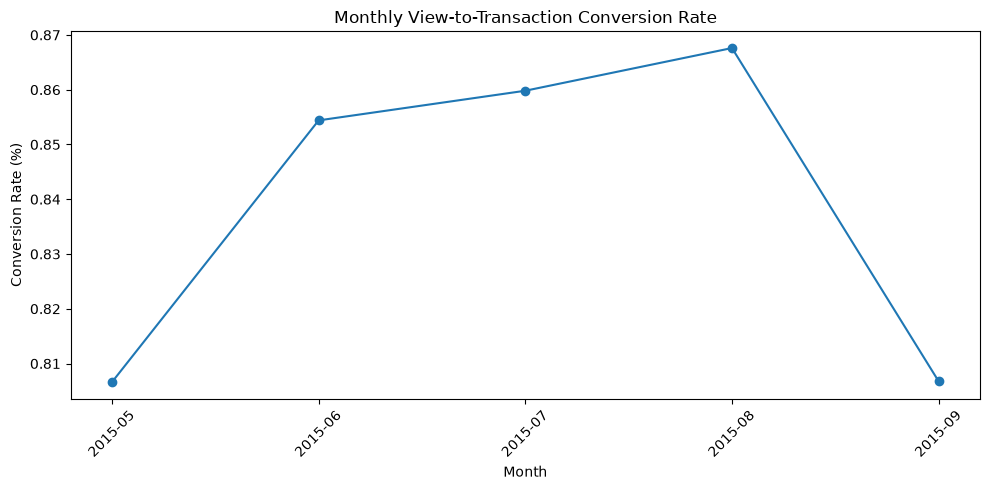

In [171]:
# Plot monthly View → Transaction conversion rate

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_event_trends["month"],
    monthly_event_trends["view_to_transaction_rate"],
    marker="o"
)

plt.title("Monthly View-to-Transaction Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

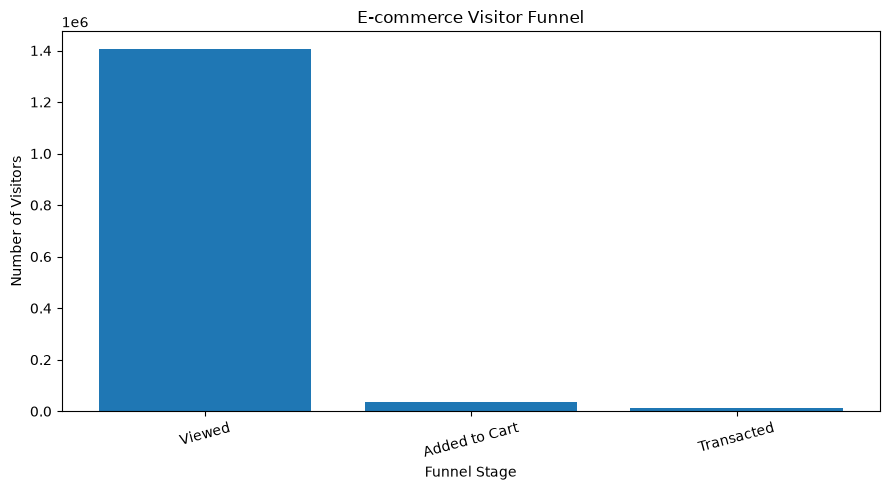

In [172]:
# Plot the visitor funnel

plt.figure(figsize=(9, 5))

plt.bar(
    funnel_summary["stage"],
    funnel_summary["visitors"]
)

plt.title("E-commerce Visitor Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Visitors")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

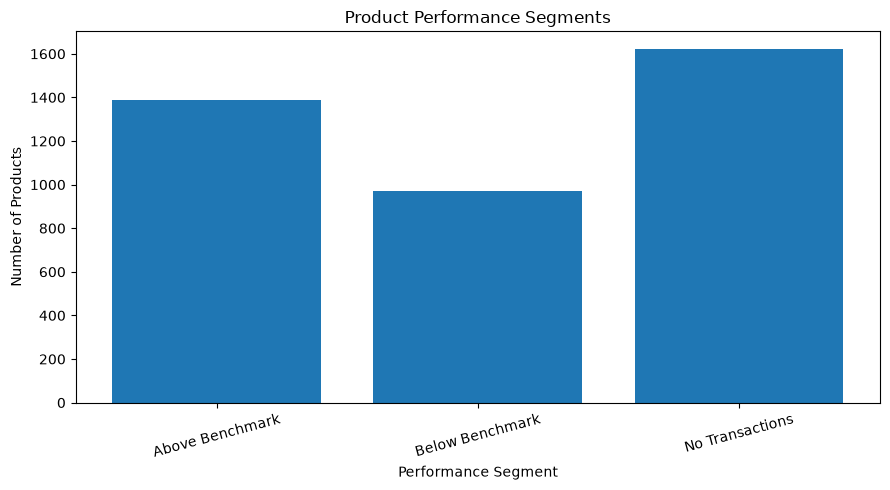

In [173]:
# Plot product performance segments

plt.figure(figsize=(9, 5))

plt.bar(
    product_segment_summary["performance_segment"],
    product_segment_summary["product_count"]
)

plt.title("Product Performance Segments")
plt.xlabel("Performance Segment")
plt.ylabel("Number of Products")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

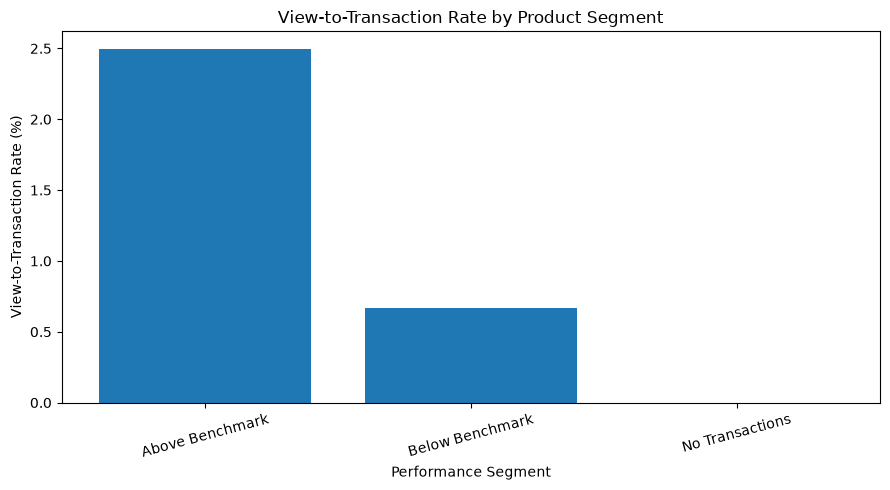

In [174]:
# Plot conversion rate by product performance segment

plt.figure(figsize=(9, 5))

plt.bar(
    product_segment_summary["performance_segment"],
    product_segment_summary["view_to_transaction_rate"]
)

plt.title("View-to-Transaction Rate by Product Segment")
plt.xlabel("Performance Segment")
plt.ylabel("View-to-Transaction Rate (%)")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

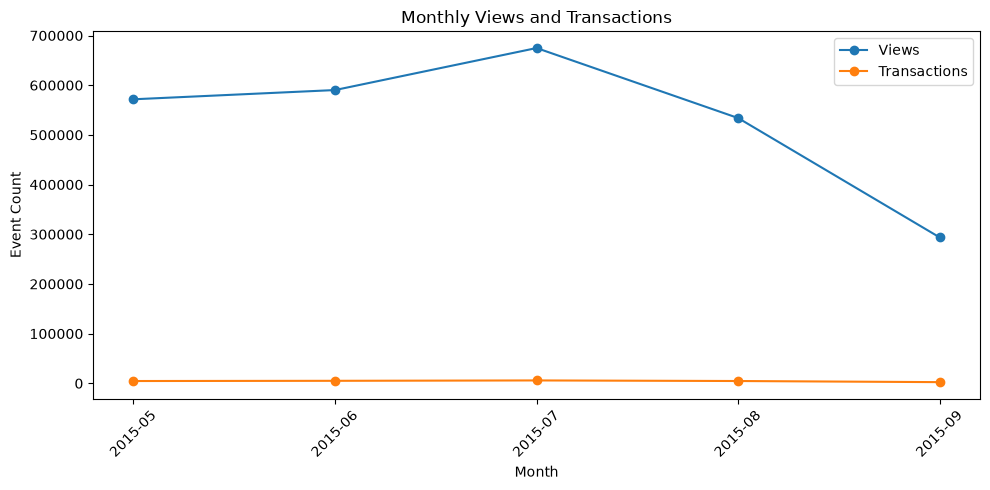

In [175]:
# Plot monthly views and transactions

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_event_trends["month"],
    monthly_event_trends["views"],
    marker="o",
    label="Views"
)

plt.plot(
    monthly_event_trends["month"],
    monthly_event_trends["transactions"],
    marker="o",
    label="Transactions"
)

plt.title("Monthly Views and Transactions")
plt.xlabel("Month")
plt.ylabel("Event Count")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

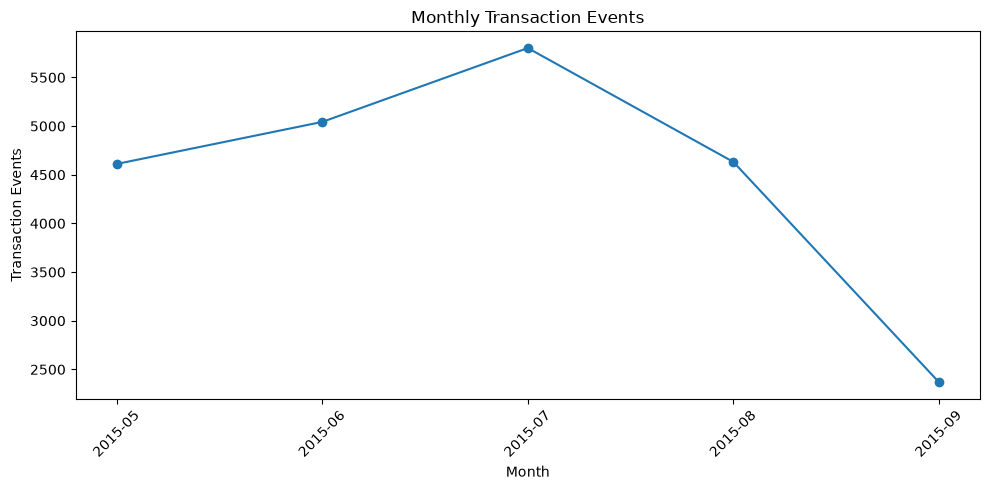

In [176]:
# Plot monthly transaction trend

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_event_trends["month"],
    monthly_event_trends["transactions"],
    marker="o"
)

plt.title("Monthly Transaction Events")
plt.xlabel("Month")
plt.ylabel("Transaction Events")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

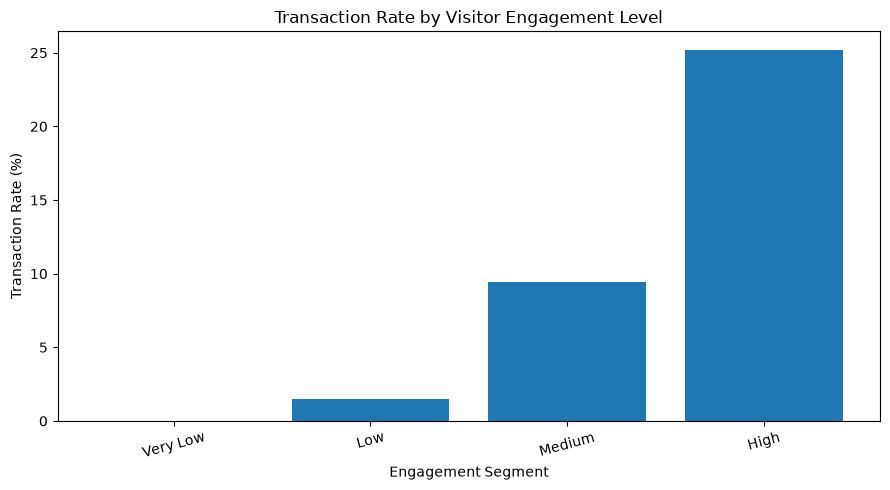

In [177]:
# Plot transaction rate by visitor engagement segment

plt.figure(figsize=(9, 5))

plt.bar(
    engagement_transaction_summary["engagement_segment"].astype(str),
    engagement_transaction_summary["transaction_rate"]
)

plt.title("Transaction Rate by Visitor Engagement Level")
plt.xlabel("Engagement Segment")
plt.ylabel("Transaction Rate (%)")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

## 12. Final Project KPIs

Create the final KPI summary for the project.


In [179]:
# Create final project KPI summary

project_kpis = pd.DataFrame({
    "KPI": [
        "Total Unique Visitors",
        "Total Product Views",
        "Total Add-to-Cart Events",
        "Total Transaction Events",
        "Visitor View-to-Cart Rate",
        "Visitor View-to-Transaction Rate",
        "Complete Funnel Rate",
        "Average Product View-to-Transaction Rate"
    ],
    "Value": [
        total_visitors,
        total_views,
        total_add_to_cart,
        total_transactions,
        visitor_view_to_cart,
        visitor_view_to_transaction,
        complete_funnel_rate,
        average_product_conversion
    ]
})

display(project_kpis)

,KPI,Value
0,Total Unique Visitors,1.407580e+06
1,Total Product Views,2.664218e+06
2,Total Add-to-Cart Events,6.896600e+04
3,Total Transaction Events,2.245700e+04
4,Visitor View-to-Cart Rate,2.686410e+00
5,Visitor View-to-Transaction Rate,8.345802e-01
6,Complete Funnel Rate,7.283972e-01
7,Average Product View-to-Transaction Rate,1.065950e+00
